### What model sees

Original Resolution in JSON: [1152, 1344]
Target Resolution: (1152, 1344)
Principal Point in K: (580.7, 681.5)

⚠️ DIAGNOSIS: K matrix looks High-Res. Scaling it down...


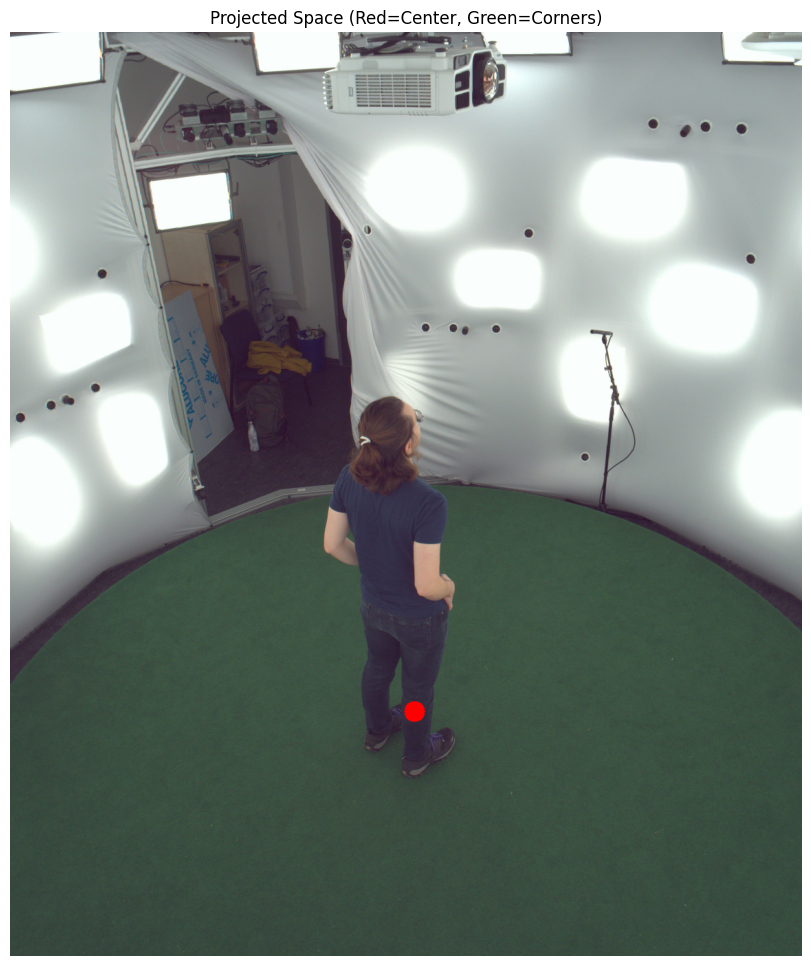

In [2]:
import numpy as np
import cv2
import json
import matplotlib.pyplot as plt
import os

# --- CONFIG ---
IMG_PATH = 'data/emre_dataset/my_seq_1/hdImgs/00_19/00_19_00000000.jpg'  # Make sure this path exists
CALIB_PATH = 'data/emre_dataset/my_seq_1/calibration_my_seq_1.json' 
TARGET_CAMERA_NAME = "00_19"  # The name inside your JSON

# Your MVGFormer Config Values
SPACE_CENTER = np.array([0.0, 0.0, 0.0]) 
SPACE_SIZE = np.array([8000.0, 8000.0, 8000.0])
# The resolution your CONFIG expects (1152x1344)
TARGET_RES = (1152, 1344) 

def project_point(point_3d, K, R, t):
    # Convert to standard format
    point_cam = R @ point_3d + t
    
    # Check if point is behind camera (Z < 0)
    if point_cam[2] <= 0: 
        return None
    
    # Project to 2D
    point_2d_homo = K @ point_cam
    u = point_2d_homo[0] / point_2d_homo[2]
    v = point_2d_homo[1] / point_2d_homo[2]
    return (int(u), int(v))

# 1. Load Image
if not os.path.exists(IMG_PATH):
    print(f"ERROR: Image not found at {IMG_PATH}")
    # Create a dummy black image so the script doesn't crash
    img = np.zeros((TARGET_RES[1], TARGET_RES[0], 3), dtype=np.uint8)
else:
    img = cv2.imread(IMG_PATH)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert for Matplotlib

# 2. Resize Image to what the Network sees
img_resized = cv2.resize(img, TARGET_RES)

# 3. Load Calibration
with open(CALIB_PATH) as f:
    full_json = json.load(f)

# Find the specific camera
cam_data = None
for cam in full_json["cameras"]:
    if cam["name"] == TARGET_CAMERA_NAME:
        cam_data = cam
        break

if cam_data is None:
    print(f"WARNING: Camera {TARGET_CAMERA_NAME} not found. Using first available.")
    cam_data = full_json["cameras"][0]

# Extract Matrix
K = np.array(cam_data['K'])
R = np.array(cam_data['R'])
t = np.array(cam_data['t']).reshape(3)
json_res = cam_data['resolution'] # [4608, 5328]

# --- CRITICAL DIAGNOSIS ---
print(f"Original Resolution in JSON: {json_res}")
print(f"Target Resolution: {TARGET_RES}")
print(f"Principal Point in K: ({K[0,2]:.1f}, {K[1,2]:.1f})")

# CHECK: Is K already scaled?
# If Width is 4608, center should be ~2304. 
# Your K has center ~580. 
# 2304 / 580 ≈ 4. 
# CONCLUSION: Your K matrix is ALREADY scaled for the small image.
if K[0,2] < 1000 and json_res[0] > 4000:
    print("\n✅ DIAGNOSIS: K matrix is ALREADY SCALING DOWN. Using as is.")
    # Do NOT scale K. It is already correct for the small image.
else:
    print("\n⚠️ DIAGNOSIS: K matrix looks High-Res. Scaling it down...")
    scale_x = TARGET_RES[0] / json_res[0]
    scale_y = TARGET_RES[1] / json_res[1]
    K[0,0] *= scale_x; K[0,2] *= scale_x
    K[1,1] *= scale_y; K[1,2] *= scale_y

# 4. Draw Space Center (Red Dot)
center_uv = project_point(SPACE_CENTER, K, R, t)
if center_uv:
    cv2.circle(img_resized, center_uv, 15, (255, 0, 0), -1) # Red
else:
    print("❌ Center Point is BEHIND the camera!")

# 5. Draw Space Box (Green Corners)
half_size = SPACE_SIZE / 2
corners = [SPACE_CENTER + np.array([x,y,z])*half_size 
           for x in [-1,1] for y in [-1,1] for z in [-1,1]]

for p in corners:
    uv = project_point(p, K, R, t)
    if uv:
        cv2.circle(img_resized, uv, 8, (0, 255, 0), -1) # Green

# 6. Display using Matplotlib (Safe for Jupyter)
plt.figure(figsize=(12, 12))
plt.imshow(img_resized)
plt.title(f"Projected Space (Red=Center, Green=Corners)")
plt.axis('off')
plt.show()

Testing Orientation with K center: (580.7, 681.5)


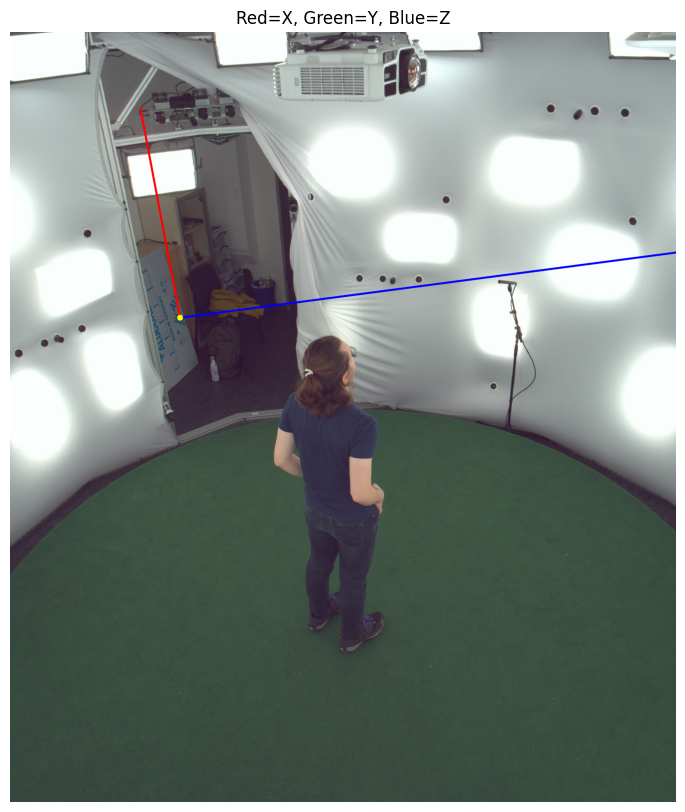

In [3]:
import numpy as np
import cv2
import json
import matplotlib.pyplot as plt
import os

# --- CONFIG ---
IMG_PATH = 'data/emre_dataset/my_seq_1/hdImgs/00_19/00_19_00000000.jpg'  # Make sure this path exists
CALIB_PATH = 'data/emre_dataset/my_seq_1/calibration_my_seq_1.json' 
TARGET_CAMERA_NAME = "00_19" # Change if needed
AXIS_LENGTH = 1000.0         # Length of lines in mm (or whatever unit your T is in)

def project_point(point_3d, K, R, t):
    # Standard Projection: P_cam = R * P_world + t
    point_cam = R @ point_3d + t
    
    # Verify point is in front of camera
    if point_cam[2] <= 0:
        return None

    # Project to pixel: p_2d = K * P_cam
    point_2d_homo = K @ point_cam
    u = int(point_2d_homo[0] / point_2d_homo[2])
    v = int(point_2d_homo[1] / point_2d_homo[2])
    return (u, v)

# 1. Load Data
img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Matplotlib expects RGB
with open(CALIB_PATH) as f:
    full_json = json.load(f)

# 2. Get Camera Params
cam_data = next((c for c in full_json["cameras"] if c["name"] == TARGET_CAMERA_NAME), full_json["cameras"][0])

K = np.array(cam_data['K'])
R = np.array(cam_data['R'])
t = np.array(cam_data['t']).reshape(3)

# --- CRITICAL: Handle the Resize Logic Manually ---
# We assume you have ALREADY fixed the JSON resolution to [1152, 1344]
# If not, we force the scale to 1.0 to check the raw matrix.
scale_x = 1.0
scale_y = 1.0
K[0,0] *= scale_x; K[0,2] *= scale_x
K[1,1] *= scale_y; K[1,2] *= scale_y

print(f"Testing Orientation with K center: ({K[0,2]:.1f}, {K[1,2]:.1f})")

# 3. Define World Axes
origin = np.array([0.0, 0.0, 0.0])
axis_x = np.array([AXIS_LENGTH, 0.0, 0.0])
axis_y = np.array([0.0, AXIS_LENGTH, 0.0])
axis_z = np.array([0.0, 0.0, AXIS_LENGTH])

# 4. Project Points
p_origin = project_point(origin, K, R, t)
p_x      = project_point(axis_x, K, R, t)
p_y      = project_point(axis_y, K, R, t)
p_z      = project_point(axis_z, K, R, t)

# 5. Draw on Image
if p_origin:
    # X-Axis (RED)
    if p_x: cv2.line(img, p_origin, p_x, (255, 0, 0), 5) 
    # Y-Axis (GREEN)
    if p_y: cv2.line(img, p_origin, p_y, (0, 255, 0), 5)
    # Z-Axis (BLUE)
    if p_z: cv2.line(img, p_origin, p_z, (0, 0, 255), 5)

    cv2.circle(img, p_origin, 10, (255, 255, 0), -1) # Yellow Origin

# 6. Show
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.title("Red=X, Green=Y, Blue=Z")
plt.axis('off')
plt.show()

In [4]:
import numpy as np
import cv2
import json
import os

# ================= CONFIGURATION =================
# Path to ONE image and its calibration file
# --- CONFIG ---
IMG_PATH = 'data/emre_dataset/my_seq_1/hdImgs/00_19/00_19_00000000.jpg'  # Make sure this path exists
CALIB_PATH = 'data/emre_dataset/my_seq_1/calibration_my_seq_1.json' 
TARGET_CAMERA_NAME = "00_19" # Your camera name

# Config Values (Must match your emre_config.yaml)
SPACE_CENTER = np.array([0.0, 0.0, 1000.0]) # Waist height in NEW coords
CUBE_SIZE = np.array([2000.0, 2000.0, 2000.0])
# =================================================

def project_box(img, K, R, t, M, label, color=(0, 255, 0)):
    # 1. Apply the Rotation M to the Camera Rotation R
    # R_new = R_old @ M
    R_new = R @ M
    
    # 2. Define the corners of the "Human Box" in the NEW World (Z-Up)
    half = CUBE_SIZE / 2
    # Bottom corners (Z=0) and Top corners (Z=2000)
    corners_new = [
        SPACE_CENTER + np.array([x, y, z]) 
        for x in [-half[0], half[0]] 
        for y in [-half[1], half[1]] 
        for z in [-half[2], half[2]]
    ]
    
    # 3. Project corners to Image
    points_2d = []
    for p in corners_new:
        # X_cam = R_new * X_new + t
        p_cam = R_new @ p + t
        
        if p_cam[2] <= 10: continue # Skip points behind camera
        
        p_homo = K @ p_cam
        u = int(p_homo[0] / p_homo[2])
        v = int(p_homo[1] / p_homo[2])
        points_2d.append((u, v))

    # 4. Draw on a copy of the image
    vis = img.copy()
    
    # Draw simple dots for corners
    for uv in points_2d:
        cv2.circle(vis, uv, 8, color, -1)
        
    # Draw a line for the "Up" axis (From Box Center-Bottom to Center-Top)
    # New World Up is Z (0,0,1). 
    bottom_center = SPACE_CENTER - np.array([0,0,1000])
    top_center = SPACE_CENTER + np.array([0,0,1000])
    
    bc_cam = R_new @ bottom_center + t
    tc_cam = R_new @ top_center + t
    
    if bc_cam[2] > 10 and tc_cam[2] > 10:
        bc_uv = (int((K@bc_cam)[0]/(K@bc_cam)[2]), int((K@bc_cam)[1]/(K@bc_cam)[2]))
        tc_uv = (int((K@tc_cam)[0]/(K@tc_cam)[2]), int((K@tc_cam)[1]/(K@tc_cam)[2]))
        cv2.arrowedLine(vis, bc_uv, tc_uv, (0, 0, 255), 5) # Red Arrow = UP
        
    cv2.putText(vis, f"Try: {label}", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    return vis

# --- MAIN ---
img_orig = cv2.imread(IMG_PATH)
if img_orig is None:
    print("Error: Image not found.")
    exit()

# Load Calib
with open(CALIB_PATH) as f:
    full_json = json.load(f)
cam_data = next((c for c in full_json["cameras"] if c["name"] == TARGET_CAMERA_NAME), full_json["cameras"][0])

K = np.array(cam_data['K'])
R = np.array(cam_data['R'])
t = np.array(cam_data['t']).reshape(3) * 10.0 # KEEP THE 10.0 scaling!

# Force Scale to 1.0 (Assuming you fixed JSON resolution)
scale = 1.0
K[0,0]*=scale; K[0,2]*=scale; K[1,1]*=scale; K[1,2]*=scale

# === CANDIDATE MATRICES ===

# 1. Identity (What you have now - X Up) -> Expect Box lying on side
M1 = np.eye(3)

# 2. Swap X and Z (The standard X-Up to Z-Up fix)
M2 = np.array([[0,0,1], 
               [0,1,0], 
               [1,0,0]])

# 3. Swap X and Z, but FLIP Y (The one that failed confidence)
M3 = np.array([[0,0,1], 
               [0,-1,0], 
               [1,0,0]])

# 4. Rotate X to Z, but keep handedness (Determinate +1)
M4 = np.array([[0,0,1],
               [0,1,0],
               [-1,0,0]])

# Generate Images
vis1 = project_box(img_orig, K, R, t, M1, "1_Identity")
vis2 = project_box(img_orig, K, R, t, M2, "2_Swap_XZ")
vis3 = project_box(img_orig, K, R, t, M3, "3_Swap_XZ_Flip_Y")
vis4 = project_box(img_orig, K, R, t, M4, "4_Rotate_NegX")

# Save them to look at
cv2.imwrite("debug_try_1.jpg", vis1)
cv2.imwrite("debug_try_2.jpg", vis2)
cv2.imwrite("debug_try_3.jpg", vis3)
cv2.imwrite("debug_try_4.jpg", vis4)

print("Saved 4 images: debug_try_1.jpg to debug_try_4.jpg.")
print("Check them and find which one has a standing GREEN BOX around the person.")

Saved 4 images: debug_try_1.jpg to debug_try_4.jpg.
Check them and find which one has a standing GREEN BOX around the person.


Calculating positions for 5 cameras...
Saved plot to 'panoptic_structure_check.png'. Open it to verify.

--- DIMENSIONS ---
X Span: 2.0
Y Span: 493.6
Z Span: 429.1


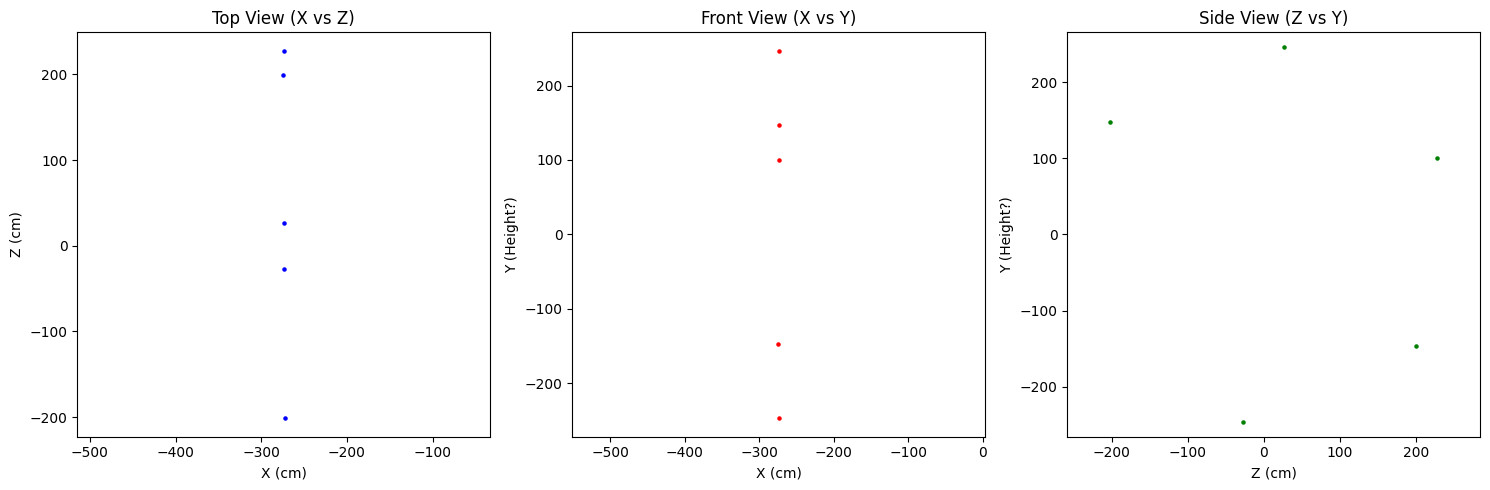

In [14]:
import numpy as np
import json
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# ================= CONFIGURATION =================
# Path to the PANOPTIC calibration file
#CALIB_PATH = 'data/panoptic/160422_haggling1/calibration_160422_haggling1.json'
CALIB_PATH = 'data/emre_dataset/my_seq_1/calibration_my_seq_1.json' 
# =================================================

def visualize_structure():
    if not os.path.exists(CALIB_PATH):
        print(f"Error: File not found at {CALIB_PATH}")
        return

    with open(CALIB_PATH) as f:
        data = json.load(f)

    centers = []
    
    print(f"Calculating positions for {len(data['cameras'])} cameras...")

    for cam in data['cameras']:
        # 1. Get R and t
        R = np.array(cam['R'])
        t = np.array(cam['t']).reshape(3, 1)
        
        # 2. Calculate Camera Center in World Coordinates
        # Formula: C = -R_transpose * t
        C = -np.dot(R.T, t)
        centers.append(C.flatten())

    centers = np.array(centers)
    
    # --- PLOTTING ---
    fig = plt.figure(figsize=(15, 5))

    # 1. Top-Down View (X vs Z) -> Checks if Floor is XZ
    ax1 = fig.add_subplot(131)
    ax1.scatter(centers[:, 0], centers[:, 2], s=5, c='b')
    ax1.set_title("Top View (X vs Z)")
    ax1.set_xlabel("X (cm)")
    ax1.set_ylabel("Z (cm)")
    ax1.axis('equal')

    # 2. Front View (X vs Y) -> Checks if Y is Height
    ax2 = fig.add_subplot(132)
    ax2.scatter(centers[:, 0], centers[:, 1], s=5, c='r')
    ax2.set_title("Front View (X vs Y)")
    ax2.set_xlabel("X (cm)")
    ax2.set_ylabel("Y (Height?)")
    ax2.axis('equal')

    # 3. Side View (Z vs Y) -> Checks if Y is Height
    ax3 = fig.add_subplot(133)
    ax3.scatter(centers[:, 2], centers[:, 1], s=5, c='g')
    ax3.set_title("Side View (Z vs Y)")
    ax3.set_xlabel("Z (cm)")
    ax3.set_ylabel("Y (Height?)")
    ax3.axis('equal')

    plt.tight_layout()
    plt.savefig("panoptic_structure_check.png")
    print("Saved plot to 'panoptic_structure_check.png'. Open it to verify.")

    # --- ANALYSIS ---
    # The axis with the largest variation that starts near 0 and goes UP is likely Height
    # The two axes that form a circle centered at 0 are the Floor.
    
    x_span = centers[:, 0].max() - centers[:, 0].min()
    y_span = centers[:, 1].max() - centers[:, 1].min()
    z_span = centers[:, 2].max() - centers[:, 2].min()
    
    print("\n--- DIMENSIONS ---")
    print(f"X Span: {x_span:.1f}")
    print(f"Y Span: {y_span:.1f}")
    print(f"Z Span: {z_span:.1f}")

if __name__ == "__main__":
    visualize_structure()